# Tutorial 03: Trích đặc trưng & Khám phá dữ liệu (EDA)
> Mục tiêu: Biến tín hiệu rung thành bảng số (features) để đưa vào mô hình ML.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sp_stats
from scipy.fft import fft, fftfreq
import os, glob

DATA_ROOT = "./data"
SAMPLE_RATE = 12000
WINDOW_SIZE = 2048
OVERLAP = 0.5

plt.rcParams.update({'figure.figsize': (12, 5), 'figure.dpi': 100, 'font.size': 12})
sns.set_style("whitegrid")
print("OK!")


OK!


## 1. Cắt segment (Windowing)

Tín hiệu dài hàng trăm nghìn mẫu → cắt thành nhiều đoạn ngắn 2048 mẫu (~0.17s), overlap 50%.


In [2]:
def segment_signal(signal, window_size=WINDOW_SIZE, overlap=OVERLAP):
    """Cắt tín hiệu thành các đoạn ngắn bằng cửa sổ trượt."""
    step = int(window_size * (1 - overlap))
    n_seg = (len(signal) - window_size) // step + 1
    return np.array([signal[i*step : i*step+window_size] for i in range(n_seg)])

# Demo
sig = np.load(os.path.join(DATA_ROOT, "0HP", "Normal_DE.npy"))
segs = segment_signal(sig)
print(f"Tín hiệu gốc: {len(sig)} mẫu")
print(f"Sau cắt: {segs.shape[0]} segments x {segs.shape[1]} mẫu/segment")
print(f"Overlap: {OVERLAP*100:.0f}%  →  Step: {int(WINDOW_SIZE*(1-OVERLAP))} mẫu")


Tín hiệu gốc: 243938 mẫu
Sau cắt: 237 segments x 2048 mẫu/segment
Overlap: 50%  →  Step: 1024 mẫu


## 2. Trích đặc trưng

Từ mỗi segment, tính ra **19 con số** mô tả đặc điểm rung:

**Miền thời gian** – phản ánh biên độ, phân bố, xung:
| Đặc trưng | Ý nghĩa |
|---|---|
| RMS | "Năng lượng" rung tổng thể |
| Peak | Biên độ lớn nhất |
| Kurtosis | Phát hiện xung va chạm (bình thường ≈ 3) |
| Crest Factor | Peak / RMS – cao khi có xung nhọn |

**Miền tần số** – phản ánh phân bố năng lượng:
| Đặc trưng | Ý nghĩa |
|---|---|
| FFT Energy | Tổng năng lượng phổ |
| Band Energy | Năng lượng trong dải tần cụ thể |


In [3]:
def extract_features(segment, fs=SAMPLE_RATE):
    """Trích 19 đặc trưng từ 1 segment."""
    f = {}
    # Miền thời gian
    f['mean'] = np.mean(segment)
    f['std'] = np.std(segment)
    f['rms'] = np.sqrt(np.mean(segment**2))
    f['peak'] = np.max(np.abs(segment))
    f['p2p'] = np.max(segment) - np.min(segment)
    f['skewness'] = sp_stats.skew(segment)
    f['kurtosis'] = sp_stats.kurtosis(segment)
    rms = f['rms']
    mean_abs = np.mean(np.abs(segment))
    f['crest_factor'] = f['peak'] / rms if rms > 0 else 0
    f['shape_factor'] = rms / mean_abs if mean_abs > 0 else 0
    f['impulse_factor'] = f['peak'] / mean_abs if mean_abs > 0 else 0
    sqrt_mean = np.mean(np.sqrt(np.abs(segment)))**2
    f['clearance_factor'] = f['peak'] / sqrt_mean if sqrt_mean > 0 else 0
    
    # Miền tần số
    n = len(segment)
    yf = np.abs(fft(segment)[:n//2])
    freqs = fftfreq(n, 1/fs)[:n//2]
    f['fft_energy'] = np.sum(yf**2) / n
    f['fft_mean'] = np.mean(yf)
    f['fft_std'] = np.std(yf)
    f['fft_skewness'] = sp_stats.skew(yf)
    f['fft_kurtosis'] = sp_stats.kurtosis(yf)
    
    for lo, hi, name in [(0,500,'0_500Hz'), (500,2000,'500_2000Hz'), (2000,6000,'2000_6000Hz')]:
        mask = (freqs >= lo) & (freqs < hi)
        f[f'energy_{name}'] = np.sum(yf[mask]**2) / n if mask.any() else 0
    return f

# Test
feat = extract_features(segs[0])
print(f"Mỗi segment -> {len(feat)} đặc trưng")


Mỗi segment -> 19 đặc trưng


## 3. Xây dựng dataset hoàn chỉnh

Đọc tất cả file .npy → cắt segment → trích đặc trưng → tạo DataFrame.


In [4]:
def parse_label(filename):
    base = filename.replace('_DE.npy','').lower()
    if 'normal' in base: return 'Normal'
    elif base.startswith('ir'): return 'IR'
    elif base.startswith('or'): return 'OR'
    elif base.startswith('b'): return 'B'
    return None

rows, labels = [], []
domains = ['0HP','1HP','2HP','3HP']

for domain in domains:
    dpath = os.path.join(DATA_ROOT, domain)
    if not os.path.isdir(dpath): continue
    for fp in sorted(glob.glob(os.path.join(dpath, "*.npy"))):
        label = parse_label(os.path.basename(fp))
        if label is None: continue
        sig = np.load(fp)
        segs = segment_signal(sig)
        for s in segs:
            rows.append(extract_features(s))
            labels.append(label)
    print(f"{domain}: done")

X_features = pd.DataFrame(rows)
y_labels = pd.Series(labels, name='fault_type')
print(f"\nDataset: {X_features.shape[0]} mau x {X_features.shape[1]} features")
print(y_labels.value_counts())


0HP: done
1HP: done
2HP: done
3HP: done

Dataset: 22594 mau x 19 features
fault_type
OR        10679
B          5458
IR         4805
Normal     1652
Name: count, dtype: int64


## 4. EDA – So sánh đặc trưng giữa các lớp lỗi


C:\Users\Admin\AppData\Local\Temp\ipykernel_17192\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_17192\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_17192\3833762583.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='label', y=feat, ax=ax,
C:\Users\Admin\AppData\Local\Temp\ipykernel_17192\3833762583.py:8: FutureWarning: 

Pass

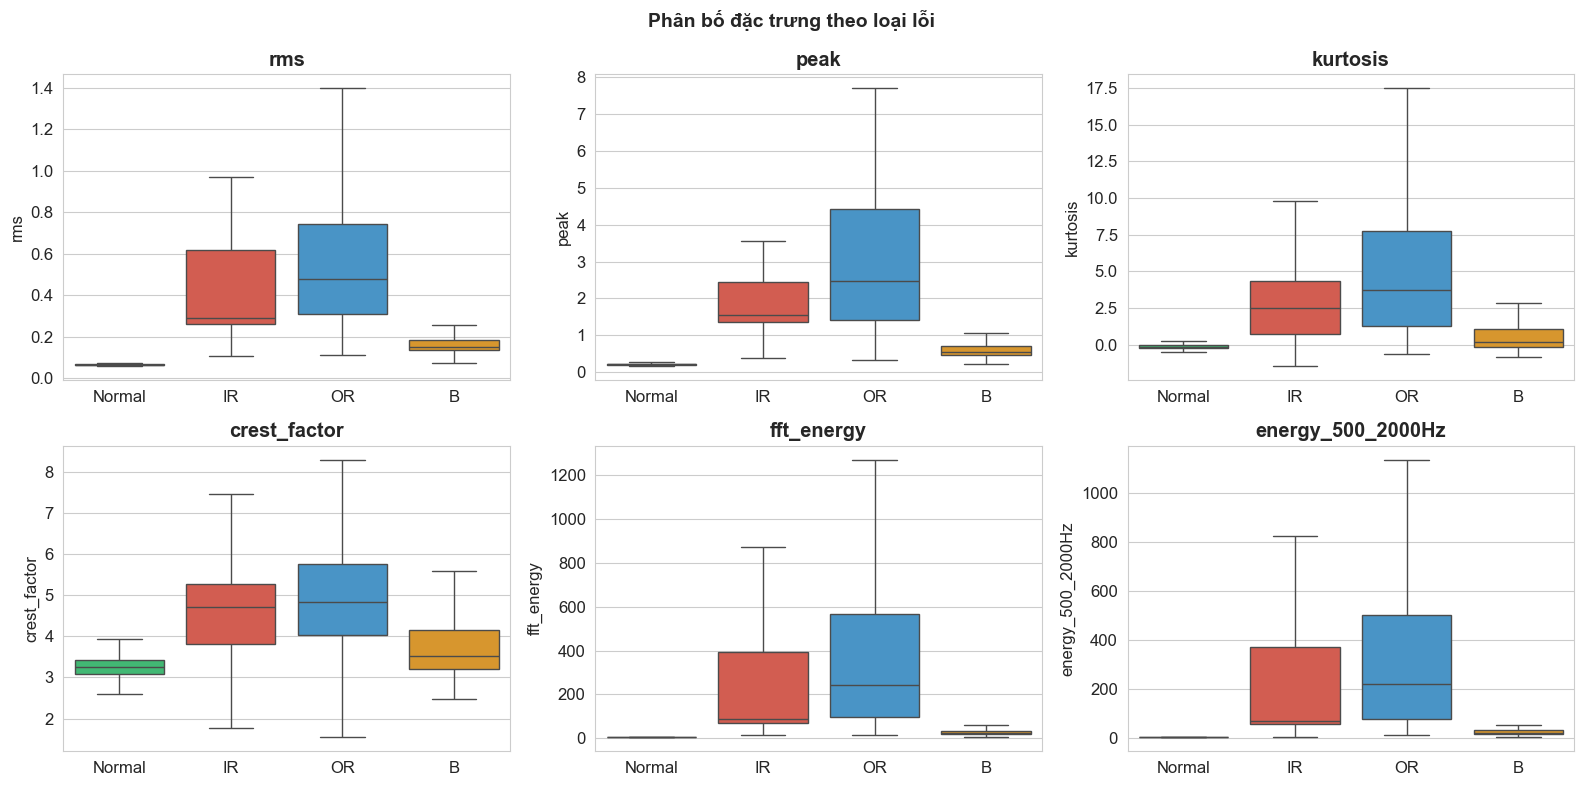

Nhận xét:
- RMS, Peak, FFT Energy: tăng rõ khi có lỗi IR/OR
- Kurtosis: rất nhạy với xung → 'chuông báo động sớm'
- Ball fault (B): khó phân biệt nhất với Normal


In [5]:
key_feats = ['rms', 'peak', 'kurtosis', 'crest_factor', 'fft_energy', 'energy_500_2000Hz']
plot_df = X_features[key_feats].copy()
plot_df['label'] = y_labels.values

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, feat in enumerate(key_feats):
    ax = axes[i//3, i%3]
    sns.boxplot(data=plot_df, x='label', y=feat, ax=ax, 
                order=['Normal','IR','OR','B'], showfliers=False,
                palette={'Normal':'#2ecc71','IR':'#e74c3c','OR':'#3498db','B':'#f39c12'})
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Phân bố đặc trưng theo loại lỗi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Nhận xét:")
print("- RMS, Peak, FFT Energy: tăng rõ khi có lỗi IR/OR")
print("- Kurtosis: rất nhạy với xung → 'chuông báo động sớm'")
print("- Ball fault (B): khó phân biệt nhất với Normal")


## 5. Lưu dataset để dùng cho Tutorial sau


In [6]:
# Lưu để các tutorial sau dùng lại (không cần trích đặc trưng lại)
X_features.to_csv("X_features.csv", index=False)
y_labels.to_csv("y_labels.csv", index=False)
print(f"Da luu: X_features.csv ({X_features.shape}), y_labels.csv ({len(y_labels)})")


Da luu: X_features.csv ((22594, 19)), y_labels.csv (22594)


## 📝 Bài tập

1. Thử `WINDOW_SIZE = 4096` → số segment thay đổi? Accuracy sau này có khác?
2. Bỏ hết feature miền tần số, chỉ giữ miền thời gian → boxplot có tách biệt đủ không?
3. Thêm 1 đặc trưng mới: **Entropy** (độ hỗn loạn) → nó giúp phân biệt lớp nào?

---
*Tutorial 03/05 – Khóa đào tạo "Ứng dụng ML trong chẩn đoán thiết bị quay"*
